<a href="https://colab.research.google.com/github/nyee88/tvam_resin_mini/blob/main/notebooks/01_working_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- Bootstrap: make paths work in Colab ---
import os, pathlib, subprocess

REPO_URL = "https://github.com/nyee88/tvam_resin_mini.git"  # your repo URL
REPO_DIR = "tvam_resin_mini"

if not pathlib.Path(REPO_DIR).exists():
    subprocess.run(["git", "clone", REPO_URL], check=True)

os.chdir(REPO_DIR)
print("CWD:", os.getcwd())
print("CSV exists?", pathlib.Path("data/ec_dp_405nm.csv").exists())


CWD: /content/tvam_resin_mini
CSV exists? True


,resin_or_source,Ec_mJ_cm2,Dp_um,wavelength_nm,notes
0,ExampleResin_A,6.5,120,405,vendor or paper link
1,ExampleResin_B,4.8,85,405,vendor or paper link
2,ExampleResin_C,10.2,200,405,vendor or paper link


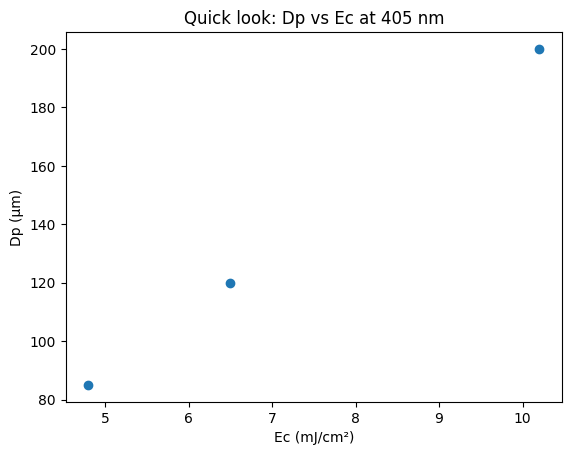

,resin_or_source,Ec_mJ_cm2,Dp_um,E_needed_mJcm2_for_100um
0,ExampleResin_A,6.5,120,14.956343
1,ExampleResin_B,4.8,85,15.565960
2,ExampleResin_C,10.2,200,16.816957


In [3]:
# --- Install minimal deps (fast) ---
!pip -q install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1) Load your tiny Ec/Dp table ---
csv_path = "data/ec_dp_405nm.csv"  # when saved back to GitHub, this relative path will work
df = pd.read_csv(csv_path, comment='#')

# Basic sanity checks
required = ["resin_or_source", "Ec_mJ_cm2", "Dp_um", "wavelength_nm"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
assert (df["wavelength_nm"] == 405).all(), "Keep wavelength at 405 nm for now."

display(df)

# --- 2) Quick plot: Dp vs Ec (both matter for exposure) ---
plt.figure()
plt.scatter(df["Ec_mJ_cm2"], df["Dp_um"])
plt.xlabel("Ec (mJ/cm²)")
plt.ylabel("Dp (µm)")
plt.title("Quick look: Dp vs Ec at 405 nm")
plt.show()

# --- 3) Tiny demo: dose needed for a target cured depth ---
# Jacobs working-curve: Cd = Dp * ln(E / Ec)  -> E = Ec * exp(Cd/Dp)
target_Cd_um = 100  # e.g., aim to fully cure ~100 µm
df["E_needed_mJcm2_for_100um"] = df.apply(
    lambda r: r["Ec_mJ_cm2"] * (2.718281828 ** (target_Cd_um / r["Dp_um"])),
    axis=1
)
display(df[["resin_or_source", "Ec_mJ_cm2", "Dp_um", "E_needed_mJcm2_for_100um"]])


In [4]:
import numpy as np

for L_um in [50, 100, 150]:
    E_needed = df["Ec_mJ_cm2"] * np.exp(L_um / df["Dp_um"])
    print(f"\nLayer L = {L_um} µm  (lower is better)")
    display(df.assign(E_for_L=E_needed)[["resin_or_source","E_for_L"]]
              .sort_values("E_for_L"))



Layer L = 50 µm  (lower is better)


,resin_or_source,E_for_L
1,ExampleResin_B,8.643877
0,ExampleResin_A,9.859829
2,ExampleResin_C,13.097059



Layer L = 100 µm  (lower is better)


,resin_or_source,E_for_L
0,ExampleResin_A,14.956343
1,ExampleResin_B,15.565960
2,ExampleResin_C,16.816957



Layer L = 150 µm  (lower is better)


,resin_or_source,E_for_L
2,ExampleResin_C,21.593400
0,ExampleResin_A,22.687229
1,ExampleResin_B,28.031302


In [5]:
# --- Method A: Learn alpha (two points per resin) and apply it globally ---

import numpy as np
import pandas as pd

# Assumes you already have df with columns: resin_or_source, Ec_mJ_cm2, Dp_um
# df.head()

# ==== 1) Config: job + temps ====
T0_C       = 23.0   # reference temperature for the vendor Ec in df (assume 23°C)
T_today    = 25.0   # <-- set today's measured temperature
I_mWcm2    = 5.0    # irradiance at resin plane (mW/cm²)
L_um       = 100    # target cured depth (≈ layer thickness)
safety     = 1.15   # small cushion

# ==== 2) Minimal calibration data: Ec at two temps per resin ====
# Replace these with your measured (or synthetic) pairs.
ec_pairs = pd.DataFrame({
    "resin_or_source": ["ExampleResin_A","ExampleResin_B","ExampleResin_C"],
    "T1_C":            [22.0, 22.0, 22.0],
    "Ec1_mJcm2":       [6.8,  5.0, 10.5],   # Ec measured at T1
    "T2_C":            [26.0, 26.0, 26.0],
    "Ec2_mJcm2":       [6.4,  4.7, 10.0],   # Ec measured at T2
})

# ==== 3) Per-resin alpha from two points: alpha = d(ln Ec)/dT ====
dT = ec_pairs["T2_C"] - ec_pairs["T1_C"]
ec_pairs["alpha_per_C"] = (np.log(ec_pairs["Ec2_mJcm2"]) - np.log(ec_pairs["Ec1_mJcm2"])) / dT

# (Optional sanity) show per-resin α
display(ec_pairs[["resin_or_source","alpha_per_C"]])

# ==== 4) Choose a global alpha (simple mean of per-resin) ====
alpha_global = ec_pairs["alpha_per_C"].mean()
print(f"Global alpha (mean): {alpha_global:.4f} per °C  (~{100*alpha_global:.1f}%/°C)")

# ==== 5) Temperature-adjust Ec to today's T and compute dose/time ====
# Assume df['Ec_mJ_cm2'] is defined at T0_C. Adjust to today's T:
Ec_T = df["Ec_mJ_cm2"] * np.exp(alpha_global * (T_today - T0_C))

# Dose for target layer with safety, then time = dose / I
E_star_T = safety * Ec_T * np.exp(L_um / df["Dp_um"])
t_star_T = E_star_T / I_mWcm2

result = df.assign(
    Ec_at_T=Ec_T,
    E_star_mJcm2=E_star_T,
    t_star_s=t_star_T
)[["resin_or_source","Ec_at_T","E_star_mJcm2","t_star_s"]].sort_values("t_star_s")

display(result)


,resin_or_source,alpha_per_C
0,ExampleResin_A,-0.015156
1,ExampleResin_B,-0.015469
2,ExampleResin_C,-0.012198


Global alpha (mean): -0.0143 per °C  (~-1.4%/°C)


,resin_or_source,Ec_at_T,E_star_mJcm2,t_star_s
0,ExampleResin_A,6.317059,16.715712,3.343142
1,ExampleResin_B,4.664905,17.397040,3.479408
2,ExampleResin_C,9.912924,18.795196,3.759039
